### IMPORT MODULES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### DATA LOAD

In [2]:
data=pd.read_csv(r"Crop_recommendation (2).csv")
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


### EXPLORATATORY DATA ANALYSIS

In [3]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
data.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [5]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
data.shape

(2200, 8)

In [8]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

### LABEL ENCODING

In [11]:
le=LabelEncoder()
data['label_encoded']=le.fit_transform(data['label'])
data

,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,5
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,5
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,5
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,5


### VISUALIZATION

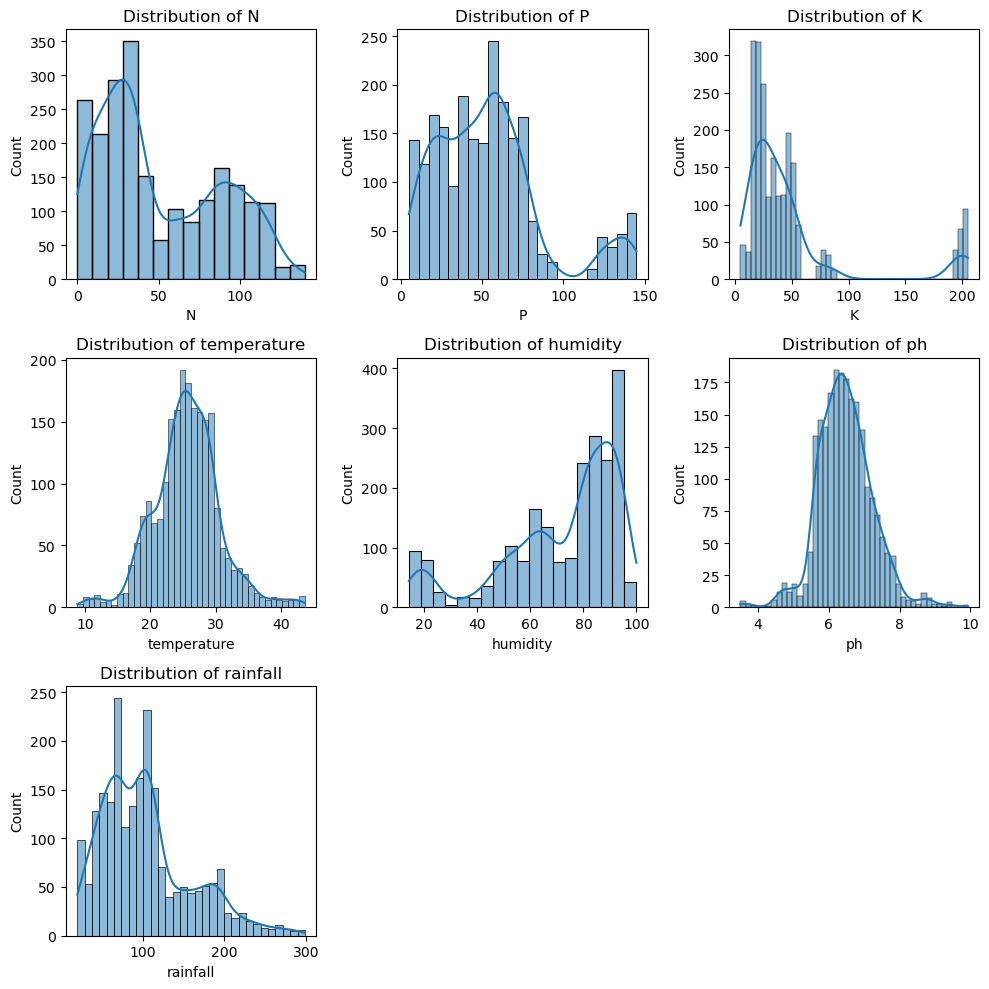

In [12]:
plt.figure(figsize=(10,10))
for i, col in enumerate(['N','P','K','temperature','humidity','ph','rainfall']):
    plt.subplot(3,3,i+1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

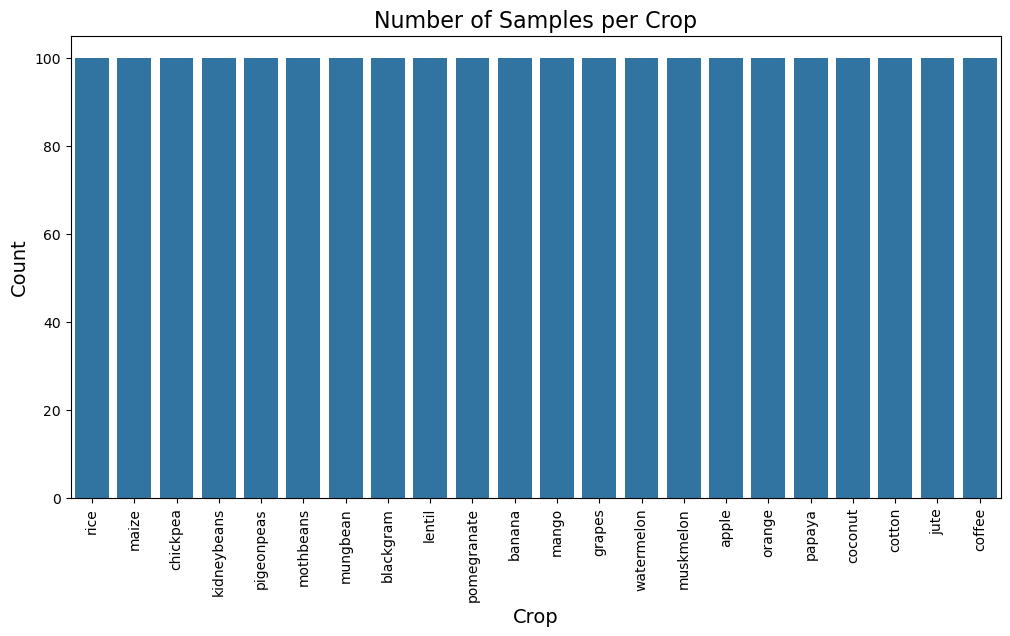

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=data)
plt.title('Number of Samples per Crop', fontsize=16)
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=90)
plt.show()

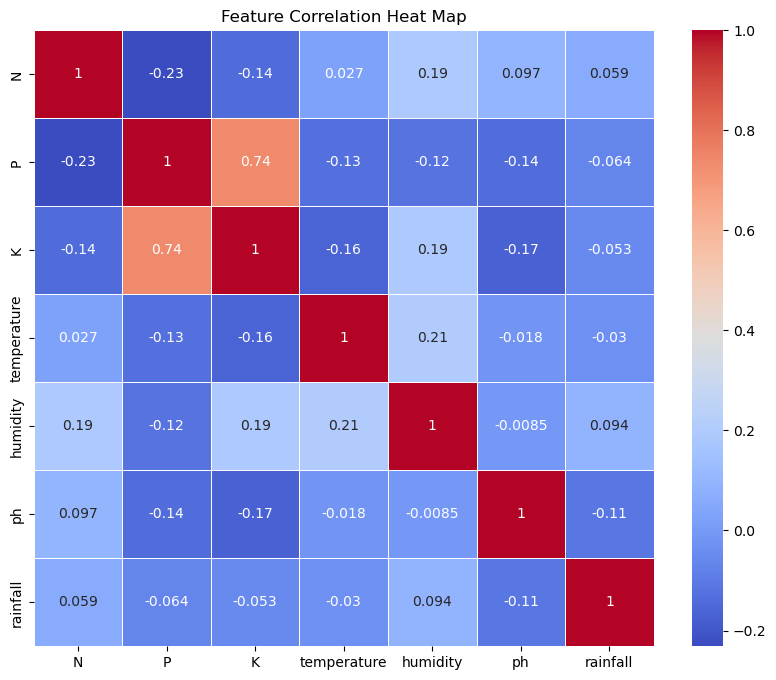

In [14]:
plt.figure(figsize=(10,8))
corr=data[['N','P','K','temperature','humidity','ph','rainfall']].corr()
sns.heatmap(corr,annot=True,linewidths=0.5,cmap='coolwarm')
plt.title('Feature Correlation Heat Map')
plt.show()

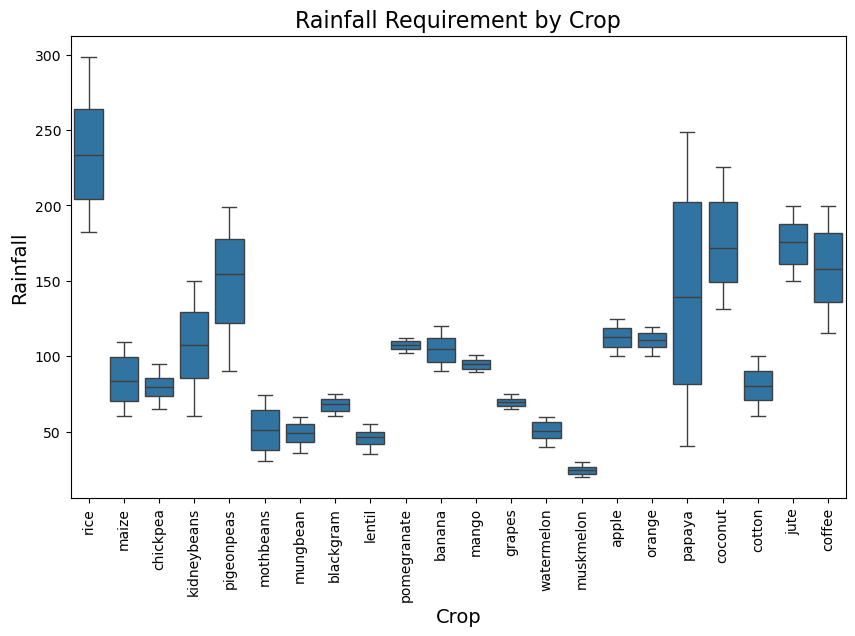

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='label', y='rainfall', data=data)
plt.title('Rainfall Requirement by Crop', fontsize=16)
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Rainfall', fontsize=14)
plt.xticks(rotation=90)
plt.show()

In [16]:
x=data.drop(['label','label_encoded'],axis=1)
x

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [17]:
y=data.label_encoded
y

0       20
1       20
2       20
3       20
4       20
        ..
2195     5
2196     5
2197     5
2198     5
2199     5
Name: label_encoded, Length: 2200, dtype: int64

In [18]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
xtrain.head()

,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725


In [20]:
ytrain.head()

1656    16
752      2
892     10
1041     1
1179    12
Name: label_encoded, dtype: int64

### MODEL CREATION

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

### LogisticRegression

In [22]:
model1=LogisticRegression(max_iter=1000)

In [23]:
model1.fit(xtrain_scaled,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
lr_pred=model1.predict(xtest_scaled)

In [25]:
lr_acc=accuracy_score(ytest,lr_pred)
lr_acc

0.9636363636363636

In [26]:
lr_precision=precision_score(ytest,lr_pred,average='weighted')
lr_precision

0.9644420567548909

In [27]:
lr_recall=recall_score(ytest,lr_pred,average='weighted')
lr_recall

0.9636363636363636

In [28]:
lr_f1=f1_score(ytest,lr_pred,average='weighted')
lr_f1

0.9635115059268677

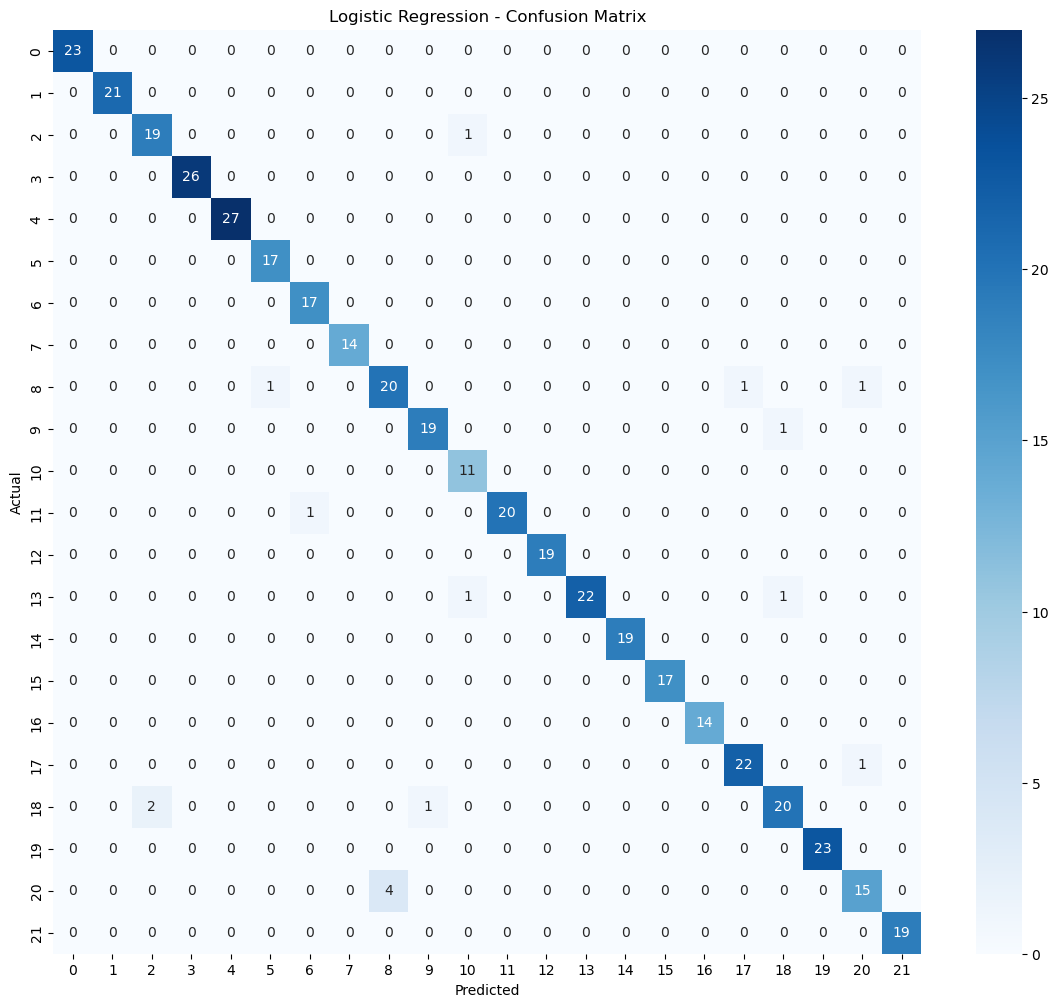

Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.95      0.93        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.83      0.87      0.85        23
           9       0.95      0.95      0.95        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00    

In [29]:
cm = confusion_matrix(ytest, lr_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Logistic Regression - Classification Report")
print(classification_report(ytest, lr_pred))

### DecisionTreeClassifier

In [30]:
model2=DecisionTreeClassifier(random_state=42)

In [31]:
model2.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
dt_pred=model2.predict(xtest)

In [33]:
dt_acc=accuracy_score(ytest,dt_pred)
dt_acc

0.9863636363636363

In [34]:
dt_precision=precision_score(ytest,dt_pred,average='weighted')
dt_precision

0.9868055555555556

In [35]:
dt_recall=recall_score(ytest,dt_pred,average='weighted')
dt_recall

0.9863636363636363

In [36]:
dt_f1=f1_score(ytest,dt_pred,average='weighted')
dt_f1

0.9863152866630287

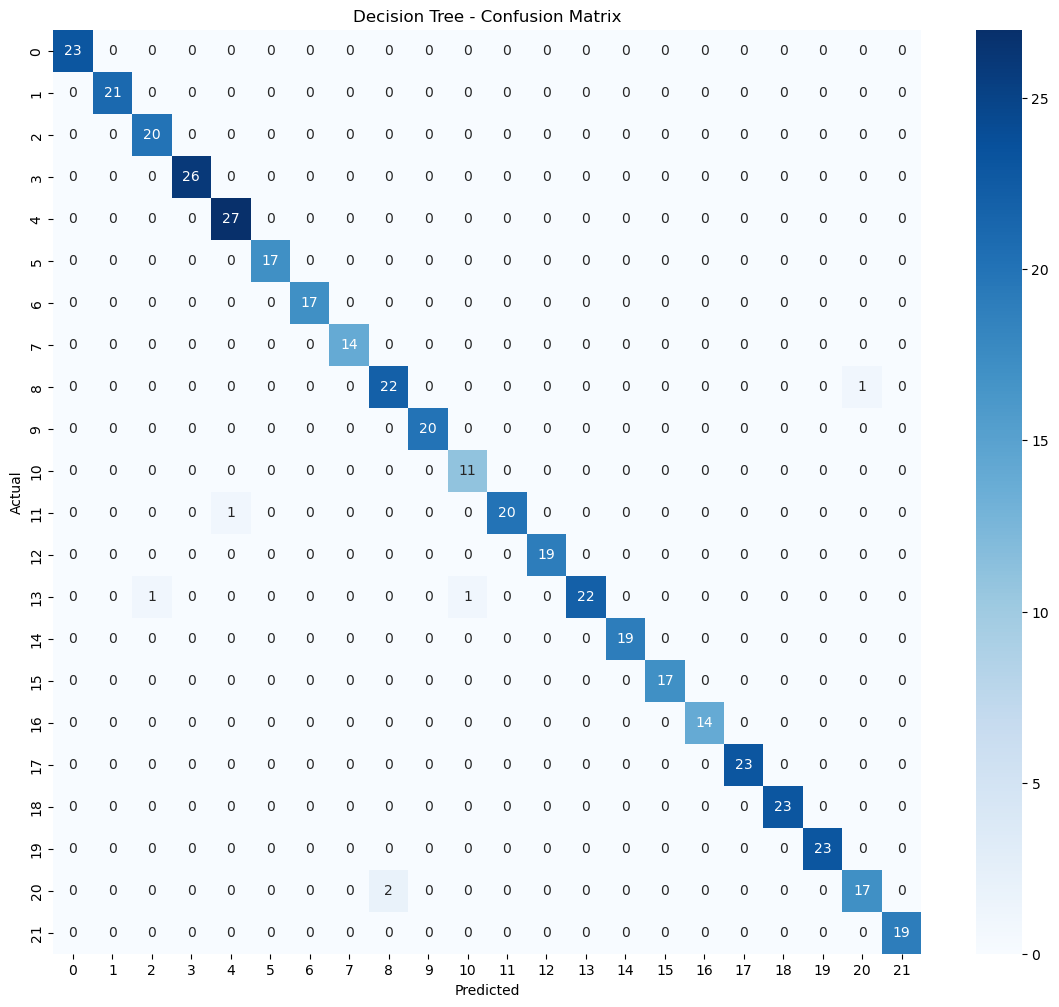

Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00

In [37]:
cm = confusion_matrix(ytest, dt_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Decision Tree - Classification Report")
print(classification_report(ytest, dt_pred))

### RandomForestClassifier

In [38]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)

In [39]:
rf.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
rf_y_pred=rf.predict(xtest)

In [41]:
rf_acc=accuracy_score(ytest,rf_y_pred)
rf_acc

0.9931818181818182

In [42]:
rf_precision=precision_score(ytest,rf_y_pred,average='weighted')
rf_precision

0.9937348484848485

In [43]:
rf_recall=recall_score(ytest,rf_y_pred,average='weighted')
rf_recall

0.9931818181818182

In [44]:
rf_f1=f1_score(ytest,rf_y_pred,average='weighted')
rf_f1

0.9931754816901672

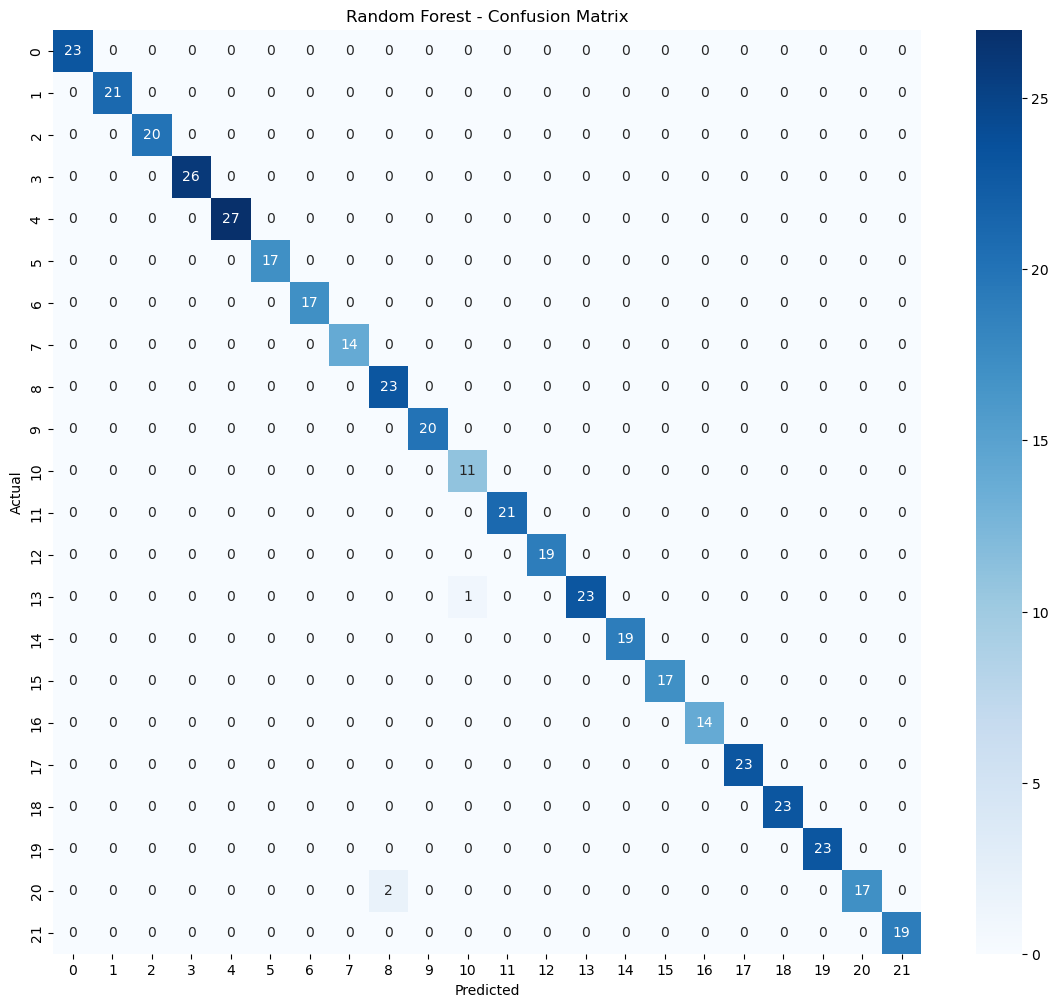

Random Forest - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00

In [45]:
cm = confusion_matrix(ytest, rf_y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Random Forest - Classification Report")
print(classification_report(ytest, rf_y_pred))

### MODEL COMPARISON

In [46]:
results = pd.DataFrame({
    'Model': ['LogisticRegression', 'DecisionTree', 'RandomForest'],
    'Accuracy': [lr_acc, dt_acc, rf_acc],
    'Precision': [lr_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, dt_recall, rf_recall],
    'F1 Score': [lr_f1, dt_f1, rf_f1]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.963636,0.964442,0.963636,0.963512
1,DecisionTree,0.986364,0.986806,0.986364,0.986315
2,RandomForest,0.993182,0.993735,0.993182,0.993175


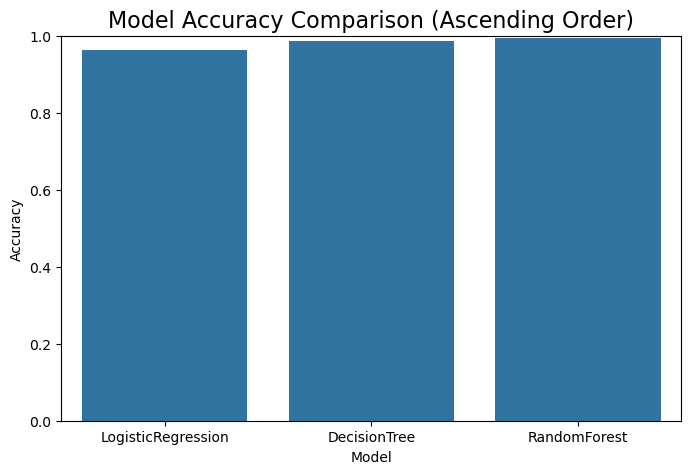

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Accuracy Comparison (Ascending Order)', fontsize=16)
plt.ylim(0,1)
plt.show()

### MAKING SIMPLE PREDICTION SYSTEM

In [48]:
input_data = pd.DataFrame([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]],
                           columns=['N','P','K','temperature','humidity','ph','rainfall'])

prediction = rf.predict(input_data)
predicted_crop = le.inverse_transform(prediction)
print(f"Recommended Crop: {predicted_crop[0]}")

Recommended Crop: rice


### SAVE MODEL

In [49]:
# save to pickle file
import pickle

In [50]:
filename='trained_crop_model.sav'
pickle.dump(rf,open(filename,'wb'))
loaded_model=pickle.load(open(filename,"rb"))
loaded_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
# Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

### IMPORT MODULES FOR USER INTERFACE USING GRADIO

In [52]:
import gradio as gr
import pickle
import numpy as np

In [53]:
! pip install gradio

In [54]:
# Load model
model = pickle.load(open("trained_crop_model.sav", "rb"))

# Load label encoder
le = pickle.load(open("label_encoder.pkl", "rb"))

# Define prediction function
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = np.array([
        N, P, K, temperature, humidity, ph, rainfall
    ]).reshape(1, -1)

    prediction = model.predict(input_data)
    predicted_crop = le.inverse_transform(prediction)
    return f"Recommended Crop: {predicted_crop[0]}"


# Create Gradio interface
iface = gr.Interface(
    fn=predict_crop,
    inputs=[
        gr.Number(label="Nitrogen (N)"),
        gr.Number(label="Phosphorus (P)"),
        gr.Number(label="Potassium (K)"),
        gr.Number(label="Temperature (°C)"),
        gr.Number(label="Humidity (%)"),
        gr.Number(label="pH"),
        gr.Number(label="Rainfall (mm)"),
    ],
    outputs="text",
    title="Crop Recommendation System",
    description="Enter soil and weather details to get the recommended crop using a trained ML model."
)

# Launch the interface
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\Nandhitha\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
